In [154]:
import os
os.environ["QT_QPA_PLATFORM_PLUGIN_PATH"] = "/usr/lib/qt/plugins/platforms"
os.environ["QT_QPA_PLATFORM"] = "xcb"

import numpy as np
import cv2 as cv
import glob

# termination criteria
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,5,0)
objp = np.zeros((6*7,3), np.float32)
objp[:,:2] = np.mgrid[0:7,0:6].T.reshape(-1,2) * 25.0  

# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane.

images = glob.glob('*.jpeg')
images.sort()
print("Found images:", images)

Found images: ['Photo from 2025-10-24 08-24-16.316164.jpeg', 'Photo from 2025-10-24 08-24-56.764921.jpeg', 'Photo from 2025-10-24 08-25-02.155318.jpeg', 'Photo from 2025-10-24 08-25-13.437533.jpeg', 'Photo from 2025-10-24 08-25-18.513603.jpeg', 'Photo from 2025-10-24 08-25-24.966769.jpeg', 'Photo from 2025-10-24 08-25-40.859821.jpeg', 'Photo from 2025-10-24 08-26-00.717665.jpeg', 'Photo from 2025-10-24 08-26-03.049382.jpeg', 'Photo from 2025-10-24 08-26-13.903387.jpeg', 'Photo from 2025-10-24 08-26-17.954987.jpeg', 'Photo from 2025-10-24 08-26-24.531842.jpeg', 'Photo from 2025-10-24 08-26-28.678883.jpeg', 'Photo from 2025-10-24 08-26-31.711309.jpeg', 'Photo from 2025-10-24 08-26-36.523496.jpeg', 'Photo from 2025-10-24 08-26-39.531640.jpeg', 'Photo from 2025-10-24 08-26-41.966061.jpeg', 'Photo from 2025-10-24 08-26-45.500908.jpeg']


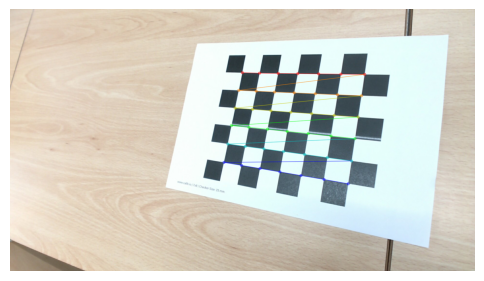

In [155]:

for fname in images:
    img = cv.imread(fname)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Find the chess board corners
    ret, corners = cv.findChessboardCorners(gray, (7,6), None)

    # If found, add object points, image points (after refining them)
    if ret == True:
        objpoints.append(objp)

        corners2 = cv.cornerSubPix(gray,corners, (11,11), (-1,-1), criteria)
        imgpoints.append(corners2)

# ...existing code...
        # Draw and display the corners using matplotlib in Jupyter
        cv.drawChessboardCorners(img, (7,6), corners2, ret)
        import matplotlib.pyplot as plt
        from IPython.display import display, clear_output
        import time

        img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        plt.figure(figsize=(6,4))
        plt.imshow(img_rgb)
        plt.axis('off')
        display(plt.gcf())
        plt.close()
        time.sleep(0.5)
        clear_output(wait=True)
# ...existing code...
# (supprimer ou ignorer cv.imshow/cv.waitKey/cv.destroyAllWindows())

In [156]:
ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
####get R by rodrigues fonction 

R = cv.Rodrigues(rvecs[0])[0]  # Convert the first rotation vector to a rotation matrix
T = tvecs[0]  # Get the first translation vector
R

array([[-0.989959  , -0.0535653 , -0.13081258],
       [ 0.06456747, -0.99459074, -0.08136526],
       [-0.12574663, -0.08899451,  0.98806263]])

In [157]:
ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

# obtenir R et T pour la meilleure vue
R = cv.Rodrigues(rvecs[0])[0]
T = tvecs[0].reshape(3,1)

# mettre à jour la matrice de projection caméra homogène si nécessaire
rotation_translation = np.hstack((R, T))
CameraProjectionMatrix = np.vstack((rotation_translation, np.array([[0,0,0,1]])))

R

array([[-0.989959  , -0.0535653 , -0.13081258],
       [ 0.06456747, -0.99459074, -0.08136526],
       [-0.12574663, -0.08899451,  0.98806263]])

In [158]:

# # Concaténer la matrice de rotation et la translation pour obtenir une matrice 3x4
# rotation_translation = np.hstack((R, T.reshape(3,1)))
# #print(rotation_translation)
# # Ajouter la dernière ligne pour obtenir une matrice 4x4 homogène
# CameraProjectionMatrix = np.vstack((rotation_translation, np.array([[0, 0, 0, 1]])))
# CameraProjectionMatrix

In [159]:
# prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,5,0)
points = objp

In [160]:
Poin_cam_repere = []
for vec in points:
    print(vec)
    vec = np.hstack((vec, 1))
    print(vec)
    Rot_trans_dot_point_scene = np.dot(CameraProjectionMatrix, vec)
    Poin_cam_repere.append(Rot_trans_dot_point_scene)
Poin_cam_repere = np.array(Poin_cam_repere)
Poin_cam_repere


[0. 0. 0.]
[0. 0. 0. 1.]
[25.  0.  0.]
[25.  0.  0.  1.]
[50.  0.  0.]
[50.  0.  0.  1.]
[75.  0.  0.]
[75.  0.  0.  1.]
[100.   0.   0.]
[100.   0.   0.   1.]
[125.   0.   0.]
[125.   0.   0.   1.]
[150.   0.   0.]
[150.   0.   0.   1.]
[ 0. 25.  0.]
[ 0. 25.  0.  1.]
[25. 25.  0.]
[25. 25.  0.  1.]
[50. 25.  0.]
[50. 25.  0.  1.]
[75. 25.  0.]
[75. 25.  0.  1.]
[100.  25.   0.]
[100.  25.   0.   1.]
[125.  25.   0.]
[125.  25.   0.   1.]
[150.  25.   0.]
[150.  25.   0.   1.]
[ 0. 50.  0.]
[ 0. 50.  0.  1.]
[25. 50.  0.]
[25. 50.  0.  1.]
[50. 50.  0.]
[50. 50.  0.  1.]
[75. 50.  0.]
[75. 50.  0.  1.]
[100.  50.   0.]
[100.  50.   0.   1.]
[125.  50.   0.]
[125.  50.   0.   1.]
[150.  50.   0.]
[150.  50.   0.   1.]
[ 0. 75.  0.]
[ 0. 75.  0.  1.]
[25. 75.  0.]
[25. 75.  0.  1.]
[50. 75.  0.]
[50. 75.  0.  1.]
[75. 75.  0.]
[75. 75.  0.  1.]
[100.  75.   0.]
[100.  75.   0.   1.]
[125.  75.   0.]
[125.  75.   0.   1.]
[150.  75.   0.]
[150.  75.   0.   1.]
[  0. 100.   0.]
[  0. 100.

array([[ 86.51156238,  55.70558891, 329.9932836 ,   1.        ],
       [ 61.7625873 ,  57.3197757 , 326.84961796,   1.        ],
       [ 37.01361222,  58.93396249, 323.70595232,   1.        ],
       [ 12.26463715,  60.54814928, 320.56228667,   1.        ],
       [-12.48433793,  62.16233606, 317.41862103,   1.        ],
       [-37.23331301,  63.77652285, 314.27495539,   1.        ],
       [-61.98228808,  65.39070964, 311.13128974,   1.        ],
       [ 85.17242992,  30.84082047, 327.76842076,   1.        ],
       [ 60.42345484,  32.45500726, 324.62475511,   1.        ],
       [ 35.67447977,  34.06919405, 321.48108947,   1.        ],
       [ 10.92550469,  35.68338084, 318.33742383,   1.        ],
       [-13.82347039,  37.29756762, 315.19375818,   1.        ],
       [-38.57244546,  38.91175441, 312.05009254,   1.        ],
       [-63.32142054,  40.5259412 , 308.9064269 ,   1.        ],
       [ 83.83329746,   5.97605203, 325.54355791,   1.        ],
       [ 59.08432239,   7

In [161]:
# Poin_cam_repere
# Poin_projection = Poin_cam_repere[:,0:2] / Poin_cam_repere[:,2][:, np.newaxis]
# Poin_projection

In [162]:
print("Camera matrix : \n"  , mtx)

Camera matrix : 
 [[1.16259781e+03 0.00000000e+00 8.92056924e+02]
 [0.00000000e+00 1.15991901e+03 5.61343119e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]


In [163]:
print("Distortion coefficients : \n", dist)

Distortion coefficients : 
 [[ 0.08548154 -0.11402643 -0.00086296  0.00011404  0.0011407 ]]


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

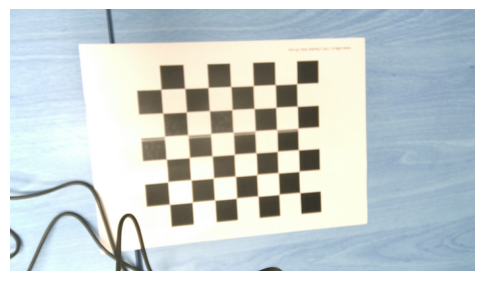

In [164]:
image_path = "Photo from 2025-10-24 08-24-16.316164.jpeg"
img_for_test = cv.imread(image_path)
plt.figure(figsize=(6,4))
plt.imshow(img_for_test)
plt.axis('off')

In [165]:
img_for_test = cv.imread(image_path)
h,  w = img_for_test.shape[:2]
newcameramtx, roi = cv.getOptimalNewCameraMatrix(mtx, dist, (w,h), 1, (w,h))

# undistort
dst = cv.undistort(img_for_test, mtx, dist, None, newcameramtx)

# # crop the image
# x, y, w, h = roi
# dst = dst[y:y+h, x:x+w]
cv.imwrite('calibresult.png', dst)

True

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

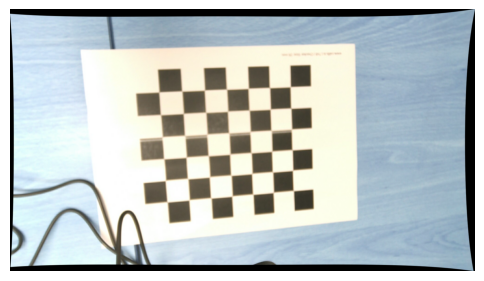

In [166]:
img_for_test = cv.imread("calibresult.png")
plt.figure(figsize=(6,4))
plt.imshow(img_for_test)
plt.axis('off')

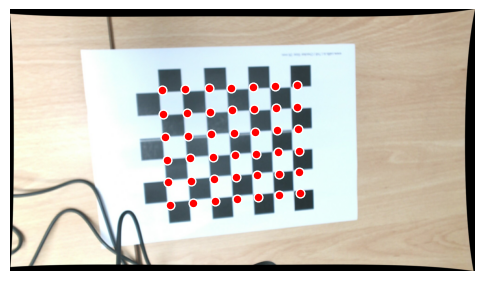

In [167]:
# afficher l'image et les points projetés
img_for_test = cv.imread("calibresult.png")
img_rgb = cv.cvtColor(img_for_test, cv.COLOR_BGR2RGB)

# Poin_cam_repere doit avoir been calculé avant : shape (N,4) ou (N,3)
# Si Poin_cam_repere est en homogène 4x1 par point (produit CameraProjectionMatrix * [X,Y,Z,1]),
# on récupère X,Y,Z comme suit :
pts_cam = Poin_cam_repere[:, :3].T  # shape (3, N)

# proj = K * [X;Y;Z]
proj = mtx.dot(pts_cam)            # shape (3, N)
proj /= proj[2, :]                 # normaliser par la 3e composante
pixel_pts = proj[:2, :].T          # shape (N,2) : (u, v) en pixels

plt.figure(figsize=(6,4))
plt.imshow(img_rgb)
plt.axis('off')

# superposer les points projetés
plt.scatter(pixel_pts[:,0], pixel_pts[:,1], c='r', s=40, marker='o', edgecolors='white')
# optionnel : numéroter les points
# for i, (u,v) in enumerate(pixel_pts):
#     plt.text(u+3, v+3, str(i), color='yellow', fontsize=8)

plt.show()
# ...existing code...

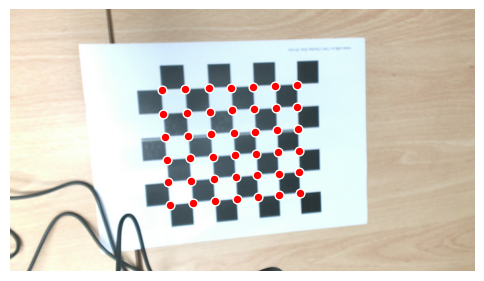

In [168]:
# afficher l'image et les points projetés

img_for_test = cv.imread(image_path)
img_rgb = cv.cvtColor(img_for_test, cv.COLOR_BGR2RGB)

# Poin_cam_repere doit avoir been calculé avant : shape (N,4) ou (N,3)
# Si Poin_cam_repere est en homogène 4x1 par point (produit CameraProjectionMatrix * [X,Y,Z,1]),
# on récupère X,Y,Z comme suit :
pts_cam = Poin_cam_repere[:, :3].T  # shape (3, N)

# proj = K * [X;Y;Z]
proj = mtx.dot(pts_cam)            # shape (3, N)
proj /= proj[2, :]                 # normaliser par la 3e composante
pixel_pts = proj[:2, :].T          # shape (N,2) : (u, v) en pixels

plt.figure(figsize=(6,4))
plt.imshow(img_rgb)
plt.axis('off')

# superposer les points projetés
plt.scatter(pixel_pts[:,0], pixel_pts[:,1], c='r', s=40, marker='o', edgecolors='white')
# optionnel : numéroter les points
# for i, (u,v) in enumerate(pixel_pts):
#     plt.text(u+3, v+3, str(i), color='yellow', fontsize=8)

plt.show()
# ...existing code...

In [169]:
mean_error = 0
for i in range(len(objpoints)):
    imgpoints2, _ = cv.projectPoints(objpoints[i], rvecs[i], tvecs[i], mtx, dist)
    error = cv.norm(imgpoints[i], imgpoints2, cv.NORM_L2)/len(imgpoints2)
    mean_error += error

print( "total error: {}".format(mean_error/len(objpoints)) )

total error: 0.09634684393756596
